# Naive Bayes variants

Four configurations of `MultinomialNB` on the balanced training partition, all evaluated on the held-out test set:

1. TF-IDF(clean_content) — bag-of-words floor, reported with 10-fold CV for a variance estimate.
2. TF-IDF(spaCy lemmas of raw content).
3. TF-IDF(clean_content) + per-document POS-tag distribution.
4. TF-IDF(clean_content) + per-document LDA topic distribution.

Each setup fits its own vectorizer on the training fold only — no leakage from the test set.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spacy

from scipy.sparse import hstack, csr_matrix
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import (
    classification_report, f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

from utils import balance_by_min_class

In [2]:
cols = ['appName', 'content', 'clean_content', 'Sentiment']
train_df = pd.read_csv('../data/train_data.csv')[cols].reset_index(drop=True)
test_df = pd.read_csv('../data/test_data.csv')[cols].reset_index(drop=True)

# Balance training set only; test set keeps its natural distribution.
print('Train counts before balancing:', train_df['Sentiment'].value_counts().to_dict())
train_df = balance_by_min_class(train_df, label_col='Sentiment', random_state=42)
print('Train counts after balancing:', train_df['Sentiment'].value_counts().to_dict())
print('Test counts (natural):       ', test_df['Sentiment'].value_counts().to_dict())

y_train = train_df['Sentiment']
y_test = test_df['Sentiment']
print(f'\nTrain: {len(train_df)} | Test: {len(test_df)}')

Train counts before balancing: {'Positive': 75538, 'Negative': 17442, 'Neutral': 4768}
Train counts after balancing: {'Positive': 4768, 'Negative': 4768, 'Neutral': 4768}
Test counts (natural):        {'Positive': 18885, 'Negative': 4361, 'Neutral': 1192}

Train: 14304 | Test: 24438


In [3]:
# Sanity checks

def _make_keys(df):
    return set(zip(df['appName'].astype(str), df['content'].astype(str)))

for name, df_ in [('train', train_df), ('test', test_df)]:
    assert df_[cols].isna().any(axis=1).sum() == 0, f'Missing core fields in {name}'
    assert (df_['content'].astype(str).str.strip() == '').sum() == 0, f'Empty content in {name}'

overlap = len(_make_keys(train_df) & _make_keys(test_df))
assert overlap == 0, f'Train/Test overlap: {overlap} duplicated (appName, content) pairs'
print('Sanity checks passed')

Sanity checks passed


## 1. NB + TF-IDF(clean_content)

10-fold CV on the training set; TF-IDF is re-fit inside each fold so scores aren't inflated by leakage.

In [ ]:
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('nb', MultinomialNB()),
])

print('Running 10-Fold Cross-Validation...')
cv_scores = cross_val_score(nb_pipeline, train_df['clean_content'], y_train, cv=10, scoring='f1_macro')
print(f'Average CV Macro F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

nb_pipeline.fit(train_df['clean_content'], y_train)
y_pred_nb = nb_pipeline.predict(test_df['clean_content'])

f1_clean = f1_score(y_test, y_pred_nb, average='macro')
print(f'\nNB on clean_content: macro F1 = {f1_clean:.4f}')
print(classification_report(y_test, y_pred_nb))

# Reuse the fitted TF-IDF matrices for the POS and LDA feature experiments below
tfidf = nb_pipeline.named_steps['tfidf']
X_tr = tfidf.transform(train_df['clean_content'])
X_te = tfidf.transform(test_df['clean_content'])

Running 10-Fold Cross-Validation...
Average CV Macro F1: 0.6051 (+/- 0.0105)

NB on clean_content: macro F1 = 0.5302
              precision    recall  f1-score   support

    Negative       0.52      0.65      0.58      4361
     Neutral       0.12      0.44      0.19      1192
    Positive       0.95      0.73      0.82     18885

    accuracy                           0.70     24438
   macro avg       0.53      0.61      0.53     24438
weighted avg       0.83      0.70      0.75     24438



## 2. spaCy pass (lemmas + POS)

One pass over RAW content of train+test, parser/NER disabled for speed. Produces both lemmatized strings and per-doc POS-tag distributions so the feature experiments below don't each re-tokenize.

In [5]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

POS_TAGS = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PROPN', 'PRON', 'AUX', 'INTJ', 'DET', 'ADP']
POS_IDX = {t: i for i, t in enumerate(POS_TAGS)}

def spacy_features(texts):
    """One spaCy pass. Returns (lemma_strings, pos_distribution_matrix)."""
    lemmas = []
    pos = np.zeros((len(texts), len(POS_TAGS)), dtype=np.float32)
    for i, doc in enumerate(nlp.pipe(texts, batch_size=256)):
        toks = [t for t in doc if not (t.is_space or t.is_punct)]
        lemmas.append(' '.join(t.lemma_.lower() for t in toks if t.lemma_.strip()))
        n = len(toks) or 1
        for t in toks:
            j = POS_IDX.get(t.pos_)
            if j is not None:
                pos[i, j] += 1.0
        pos[i] /= n
    return lemmas, pos

print('Processing train...')
train_lemmas, pos_train = spacy_features(train_df['content'].astype(str).tolist())
print('Processing test...')
test_lemmas, pos_test = spacy_features(test_df['content'].astype(str).tolist())
print('Done')

Processing train...
Processing test...
Done


## 3. NB on lemmatized text

In [6]:
tfidf_l = TfidfVectorizer(max_features=5000)
X_tr_l = tfidf_l.fit_transform(train_lemmas)
X_te_l = tfidf_l.transform(test_lemmas)

nb_lemma = MultinomialNB().fit(X_tr_l, y_train)
f1_lemma = f1_score(y_test, nb_lemma.predict(X_te_l), average='macro')
print(f'NB on lemmatized content: macro F1 = {f1_lemma:.4f}')

NB on lemmatized content: macro F1 = 0.5303


## 4. NB on TF-IDF + POS-tag distribution

POS distributions are per-doc frequencies across the ten tags in `POS_TAGS`, all in [0, 1] — non-negative, so MultinomialNB accepts them alongside TF-IDF.

In [7]:
X_tr_pos = hstack([X_tr, csr_matrix(pos_train)])
X_te_pos = hstack([X_te, csr_matrix(pos_test)])

nb_pos = MultinomialNB().fit(X_tr_pos, y_train)
f1_pos = f1_score(y_test, nb_pos.predict(X_te_pos), average='macro')
print(f'NB on TF-IDF + POS distribution: macro F1 = {f1_pos:.4f}')

NB on TF-IDF + POS distribution: macro F1 = 0.5574


## 5. NB on TF-IDF + LDA topic distribution

Fits LDA on the training fold only, then transforms both train and test to topic-probability vectors and concatenates them to the TF-IDF matrix.

In [8]:
N_TOPICS = 10

cv = CountVectorizer(max_features=5000, stop_words='english')
C_tr = cv.fit_transform(train_df['clean_content'])
C_te = cv.transform(test_df['clean_content'])

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    learning_method='online',
)
lda.fit(C_tr)
lda_tr = lda.transform(C_tr)
lda_te = lda.transform(C_te)

X_tr_lda = hstack([X_tr, csr_matrix(lda_tr)])
X_te_lda = hstack([X_te, csr_matrix(lda_te)])

nb_lda = MultinomialNB().fit(X_tr_lda, y_train)
f1_lda = f1_score(y_test, nb_lda.predict(X_te_lda), average='macro')
print(f'NB on TF-IDF + LDA({N_TOPICS} topics): macro F1 = {f1_lda:.4f}')

NB on TF-IDF + LDA(10 topics): macro F1 = 0.5589


## 6. LDA topics vs. sentiment

Top words per topic, then the mean topic weight for each sentiment class on the training set — shows which topics lean Positive, Negative, or Neutral.

In [9]:
feature_names = cv.get_feature_names_out()
print('Top words per LDA topic:')
for k, topic in enumerate(lda.components_):
    top = [feature_names[i] for i in topic.argsort()[:-11:-1]]
    print(f'  Topic {k:>2}: {" ".join(top)}')

topic_cols = [f'T{i}' for i in range(N_TOPICS)]
topic_df = pd.DataFrame(lda_tr, columns=topic_cols)
topic_df['Sentiment'] = y_train.values
print('\nMean topic weight per sentiment class (train):')
print(topic_df.groupby('Sentiment').mean().round(3))

Top words per LDA topic:
  Topic  0: new chat super change know awesome thing add instead start
  Topic  1: hai answers slow photo asked bahut photos students app nahi
  Topic  2: nice answer time app information long gives assistant understand use
  Topic  3: like dont im want doesnt help voice limit claude problem
  Topic  4: app best ai love use useful messages claude apps day
  Topic  5: good app chat bad wrong chatgpt working really ai gpt
  Topic  6: app great helpful phone amazing number times need code dont
  Topic  7: gemini better ai image google ask response work chats worst
  Topic  8: questions hours usage accurate coding real available info quick intelligent
  Topic  9: free version pro claude limits subscription use paid like experience

Mean topic weight per sentiment class (train):
              T0     T1     T2     T3     T4     T5     T6     T7     T8  \
Sentiment                                                                  
Negative   0.069  0.082  0.110  0.135 

## 7. Summary

In [10]:
summary = pd.DataFrame([
    {'system': 'NB + TF-IDF(clean_content)',         'macro_f1': round(f1_clean, 4)},
    {'system': 'NB + TF-IDF(lemmas)',                'macro_f1': round(f1_lemma, 4)},
    {'system': 'NB + TF-IDF(clean_content) + POS',   'macro_f1': round(f1_pos, 4)},
    {'system': f'NB + TF-IDF(clean_content) + LDA{N_TOPICS}', 'macro_f1': round(f1_lda, 4)},
])
print(summary.to_string(index=False))

                            system  macro_f1
        NB + TF-IDF(clean_content)    0.5302
               NB + TF-IDF(lemmas)    0.5303
  NB + TF-IDF(clean_content) + POS    0.5574
NB + TF-IDF(clean_content) + LDA10    0.5589


## 8. Error analysis

Confusion matrix (row-normalized) and per-app macro F1 for the NB baseline on the held-out test set.

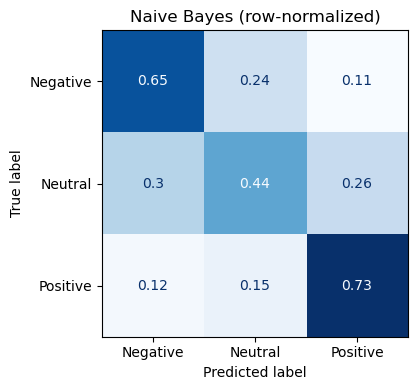

In [11]:
labels = ['Negative', 'Neutral', 'Positive']
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nb, labels=labels, ax=ax, cmap='Blues', normalize='true', colorbar=False
)
ax.set_title('Naive Bayes (row-normalized)')
plt.tight_layout()
plt.show()

In [12]:
# Per-app macro F1 breakdown
test_df = test_df.copy()
test_df['nb_prediction'] = y_pred_nb

rows = []
for app in sorted(test_df['appName'].unique()):
    sub = test_df[test_df['appName'] == app]
    rows.append({
        'appName': app,
        'n': len(sub),
        'macro_f1': round(f1_score(sub['Sentiment'], sub['nb_prediction'], average='macro'), 4),
    })
print('Naive Bayes per-app macro F1:')
print(pd.DataFrame(rows).to_string(index=False))

Naive Bayes per-app macro F1:
appName     n  macro_f1
ChatGPT 10028    0.5071
 Claude  5716    0.5550
 Gemini  8694    0.5303
